In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("churn-bigml-80.csv")

print(df.head())
print(df.info())


  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1             27.47   

In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

print(df.head())

   State  Account length  Area code  International plan  Voice mail plan  \
0     16             128        415                   0                1   
1     35             107        415                   0                1   
2     31             137        415                   0                0   
3     35              84        408                   1                0   
4     36              75        415                   1                0   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1   

In [3]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2132, 19)
(534, 19)


In [4]:
from sklearn.ensemble import RandomForestClassifier

# Create model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [5]:
# Predictions
y_pred = model.predict(X_test)

print(y_pred[:10])

[ True False False  True  True False False False False False]


In [6]:
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Precision: 0.9803921568627451
Recall: 0.6329113924050633
F1 Score: 0.7692307692307693

Classification Report:

              precision    recall  f1-score   support

       False       0.94      1.00      0.97       455
        True       0.98      0.63      0.77        79

    accuracy                           0.94       534
   macro avg       0.96      0.82      0.87       534
weighted avg       0.95      0.94      0.94       534



In [7]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:", scores)

print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.95318352 0.94371482 0.96060038 0.95309568 0.95684803]
Average CV Score: 0.9534884864838278


In [8]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:", scores)

print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.95318352 0.94371482 0.96060038 0.95309568 0.95684803]
Average CV Score: 0.9534884864838278


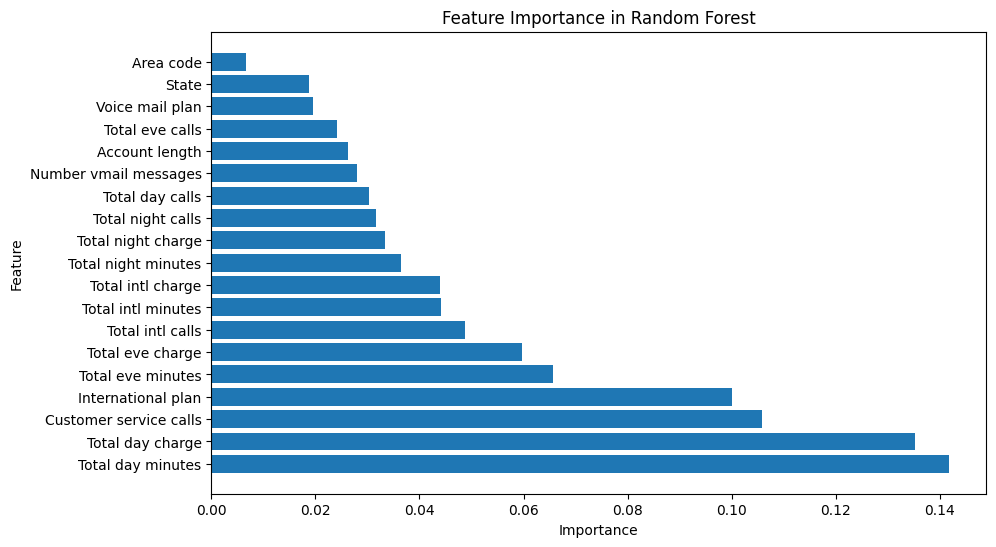

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
importance = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})

# Sort the features by importance
importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Feature Importance in Random Forest")

plt.show()